# Aggregate LRT results → Chi-square Comparison (calibration vs test)

Analogous to `LRT/Normalizing_Flows/analyse_LRT_output_ML4PS_style.ipynb` but for the Sparker kernels pipeline.

Scans the output tree for `seed{N}_T.npy` under:
- `<run_tag>/calibration/seed*/` — REF (calibration toys, H0: data from ensemble)
- `<run_tag>/test/seed*/`        — DATA (test toys, target distribution)

**Note on T scaling:** `LRT.py` saves `T = log L_num - log L_den`.
Empirically, the saved T follows χ²(DOF) directly under H0 (median T ≈ median χ²(DOF)).
Use `SCALE_T = 1` to plot T directly with a χ²(DOF) overlay.
`SCALE_T = 2` is available but the chi2 overlay will be scaled accordingly.

In [29]:
import os, glob, math
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from matplotlib.patches import Rectangle
from scipy.stats import norm, chi2, beta

plt.rcParams["font.family"] = "serif"
plt.style.use('classic')

# --- User config ---
RESULTS_BASE = "/work/gbadarac/MonoJet_NPLM/MonoJet_NPLM_analysis/LRT/Sparker_kernels/results"
RUN_TAG      = "SparKer60_Ntest100000_M100_W0.3_L10000_clip0.001_wifi_fix_normalization"

BASE_DIR = os.path.join(RESULTS_BASE, RUN_TAG)
FIG_DIR  = os.path.join(BASE_DIR, "plots")
os.makedirs(FIG_DIR, exist_ok=True)

# Empirically T (saved by LRT.py) ~ chi2(DOF) directly under H0.
# Use SCALE_T = 1 to plot T with chi2(DOF) overlay.
SCALE_T = 1

DOF   = 100    # number of extra parameters in the numerator (kernel coefficients)
NBINS = 30
XMIN  = 0
XMAX  = 600
YMAX  = None

In [30]:
def _collect_mode_T(base_dir, mode, scale=1.0):
    """
    Scan base_dir/<mode>/seed*/seed*_T.npy and return a 1-D float array.
    T values are multiplied by `scale` before returning.
    Prints which seeds are missing or non-finite.
    """
    seed_dirs = sorted(glob.glob(os.path.join(base_dir, mode, "seed*")))
    values = []
    bad = []
    for sd in seed_dirs:
        seed_name = os.path.basename(sd)
        npy_files = glob.glob(os.path.join(sd, f"{seed_name}_T.npy"))
        if not npy_files:
            bad.append((sd, "no T.npy found"))
            continue
        try:
            val = float(np.load(npy_files[0])) * scale
        except Exception as e:
            bad.append((sd, str(e)))
            continue
        if not np.isfinite(val):
            bad.append((sd, f"non-finite T = {val}"))
        else:
            values.append(val)

    print(f"[{mode}] good: {len(values)}, bad/missing: {len(bad)}")
    for sd, reason in bad:
        print(f"  BAD {os.path.basename(sd)}: {reason}")
    return np.asarray(values, dtype=float)

In [31]:
def empirical_Z_from_toys(T_null, T_obs, alternative="greater", alpha=0.32):
    """
    Empirical Z (one-sided) with exact Clopper-Pearson interval on p.
    Returns: Z, Z_plus, Z_minus, p_hat
    """
    T_null = np.asarray(T_null, float)
    B = T_null.size

    if alternative == "greater":
        k = int(np.count_nonzero(T_null >= T_obs))
    elif alternative == "less":
        k = int(np.count_nonzero(T_null <= T_obs))
    else:
        T0 = float(np.median(T_null))
        k  = int(np.count_nonzero(np.abs(T_null - T0) >= np.abs(T_obs - T0)))

    p_hat = (k + 1) / (B + 1)   # add-one estimate (robust at k=0 or k=B)

    if k == 0:
        p_lo = 0.0
        p_hi = beta.ppf(1 - alpha/2, 1, B)
    elif k == B:
        p_lo = beta.ppf(alpha/2, B, 1)
        p_hi = 1.0
    else:
        p_lo = beta.ppf(alpha/2,     k,     B - k + 1)
        p_hi = beta.ppf(1 - alpha/2, k + 1, B - k)

    Z       = norm.ppf(1 - p_hat)
    Z_plus  = norm.ppf(1 - max(1e-16, p_lo))          - Z
    Z_minus = Z - norm.ppf(1 - min(1 - 1e-16, p_hi))
    return Z, Z_plus, Z_minus, p_hat

In [32]:
def fd_bins(x):
    x = np.asarray(x, float)
    if len(x) < 2:
        return 5
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    h   = 2 * iqr / (len(x) ** (1/3) + 1e-12)
    if h <= 0:
        return 10
    return max(5, int(np.ceil((x.max() - x.min()) / h)))


def _safe_xlim(t_all, xmin, xmax, pad_frac=0.05):
    t_all = np.asarray(t_all, float)
    dmin, dmax = np.min(t_all), np.max(t_all)
    if not (np.isfinite(dmin) and np.isfinite(dmax) and dmin < dmax):
        return xmin, xmax
    bad = (xmin is None or xmax is None or xmin >= xmax
           or dmax < xmin or dmin > xmax)
    if bad:
        span = dmax - dmin
        pad  = pad_frac * span if span > 0 else 1.0
        return dmin - pad, dmax + pad
    return xmin, xmax


def plot_T_distributions(
    t_calib, t_test, output_path,
    nbins=None, save=True,
    label1='REF (calibration, H$_0$)',
    label2='DATA (test, target)',
    save_name='T_distribution_Sparker',
    ymax=None,
    title='Sparker kernels LRT',
    xmin=None, xmax=None,
    show_chi2=True,
    dof=100,
    scale_t=1,
):
    """
    Two-panel figure: main histogram + right side-panel with statistics.
    t_calib, t_test : already-scaled T arrays (multiply by SCALE_T before passing)
    scale_t         : used for axis label and chi2 overlay logic
    """
    plt.rcParams["font.family"] = "serif"
    plt.style.use('classic')
    plt.rcParams['patch.edgecolor'] = 'none'
    plt.rcParams['patch.linewidth'] = 0.0

    t_calib = np.asarray(t_calib, float)
    t_test  = np.asarray(t_test,  float)

    fig = plt.figure(figsize=(12, 9))
    fig.patch.set_facecolor('white')
    ax  = fig.add_axes([0.10, 0.12, 0.62, 0.78])
    axp = fig.add_axes([0.76, 0.12, 0.20, 0.78])
    axp.axis('off')

    # --- bins ---
    t_all = np.concatenate([t_calib, t_test]) if len(t_test) else t_calib
    if nbins is None:
        nbins = fd_bins(t_all)
    xmin_eff, xmax_eff = _safe_xlim(t_all, xmin, xmax)
    bins      = np.linspace(xmin_eff, xmax_eff, nbins + 1)
    binswidth = (xmax_eff - xmin_eff) / nbins
    xcenters  = 0.5 * (bins[1:] + bins[:-1])

    # --- calibration histogram (REF) ---
    h1 = ax.hist(
        t_calib,
        weights=np.ones_like(t_calib) / (t_calib.shape[0] * binswidth),
        color="#e186ed", alpha=0.5, bins=bins, label=label1,
        edgecolor='none', linewidth=0
    )
    err1 = np.sqrt(h1[0] / (t_calib.shape[0] * binswidth))
    ax.errorbar(xcenters, h1[0], yerr=err1,
                color="#8a2be2", marker='o', ls='', alpha=0.6,
                markersize=5, capsize=2, elinewidth=0.8)

    # --- chi2 overlay ---
    # Empirically T ~ chi2(dof) under H0 (scale_t=1).
    # scale_t=1: overlay chi2(dof) directly.
    # scale_t=2: data is 2T; pdf_{2T}(x) = chi2_pdf(x/2, dof) / 2.
    if show_chi2:
        x_chi2 = np.linspace(max(0.1, xmin_eff), xmax_eff, 500)
        if scale_t == 1:
            y_chi2     = chi2.pdf(x_chi2, df=dof)
            chi2_label = rf'$\chi^2({dof})$'
        else:
            y_chi2     = 0.5 * chi2.pdf(0.5 * x_chi2, df=dof)
            chi2_label = rf'$\chi^2({dof})$ (scaled)'
        ax.plot(x_chi2, y_chi2, 'k--', lw=1.5, label=chi2_label)

    # --- test histogram (DATA) ---
    p_emp = Z_emp_val = Z_emp_p = Z_emp_m = np.nan
    if len(t_test):
        h2 = ax.hist(
            t_test,
            weights=np.ones_like(t_test) / (t_test.shape[0] * binswidth),
            color="#68aedc", alpha=0.5, bins=bins, label=label2,
            edgecolor='none', linewidth=0
        )
        err2 = np.sqrt(h2[0] / (t_test.shape[0] * binswidth))
        ax.errorbar(xcenters, h2[0], yerr=err2,
                    color="#004c99", marker='o', ls='', alpha=0.6,
                    markersize=5, capsize=2, elinewidth=0.8)

        T_obs = float(np.median(t_test))
        Z_emp_val, Z_emp_p, Z_emp_m, p_emp = empirical_Z_from_toys(
            t_calib, T_obs, alternative="greater", alpha=0.32
        )

    # --- side panel ---
    panel_fp = font_manager.FontProperties(family='serif', size=20)
    axp.text(0.03, 0.98, rf'$N_{{\mathrm{{calib}}}} = {len(t_calib)}$',
             va='top', ha='left', fontproperties=panel_fp)
    if len(t_test):
        axp.text(0.03, 0.92, rf'$N_{{\mathrm{{test}}}} = {len(t_test)}$',
                 va='top', ha='left', fontproperties=panel_fp)

    SW, GAP = 0.032, 0.012

    def _header(y, color_hex, text):
        axp.add_patch(Rectangle((0.03, y - SW/2), SW, SW,
                                transform=axp.transAxes,
                                facecolor=color_hex, edgecolor='none', alpha=0.5))
        axp.text(0.03 + SW + GAP, y, text,
                 va='center', ha='left', fontproperties=panel_fp, color='black')

    Y_REF_HDR = 0.82
    _header(Y_REF_HDR, "#e186ed", label1)
    axp.text(0.03 + SW + GAP, Y_REF_HDR - 0.065,
             rf'median $= {np.median(t_calib):.1f}$' + '\n'
             + rf'std $= {np.std(t_calib):.1f}$',
             va='top', ha='left', fontproperties=panel_fp)

    if len(t_test):
        Y_DATA_HDR = 0.60
        _header(Y_DATA_HDR, "#68aedc", label2)
        axp.text(0.03 + SW + GAP, Y_DATA_HDR - 0.065,
                 rf'median $= {np.median(t_test):.1f}$' + '\n'
                 + rf'std $= {np.std(t_test):.1f}$',
                 va='top', ha='left', fontproperties=panel_fp)
        axp.text(0.03 + SW + GAP, Y_DATA_HDR - 0.195,
                 rf'p-value $= {p_emp:.4f}$' + '\n'
                 + rf'emp. $Z = {Z_emp_val:.2f}\,^{{+{Z_emp_p:.2f}}}_{{-{Z_emp_m:.2f}}}$',
                 va='top', ha='left', fontproperties=panel_fp)

    legend_fp = font_manager.FontProperties(family='serif', size=16.5)
    ax.legend(ncol=1, loc='upper right', prop=legend_fp, frameon=False,
              handlelength=1.8, borderpad=0.3, labelspacing=0.3)
    xlabel = r'$2t$' if scale_t == 2 else r'$t$'
    ax.set_xlabel(xlabel, fontsize=32, fontname="serif")
    ax.set_ylabel('Probability density', fontsize=28, fontname="serif")
    ax.set_xlim(xmin_eff, xmax_eff)
    if ymax is not None:
        ax.set_ylim(0., ymax)
    ax.tick_params(axis='x', labelsize=22)
    ax.tick_params(axis='y', labelsize=22)
    if title:
        ax.set_title(title, fontsize=28, fontname="serif", pad=14)

    if save:
        os.makedirs(output_path, exist_ok=True)
        base = os.path.join(output_path, save_name)
        fig.savefig(base + ".pdf", bbox_inches="tight", pad_inches=0)
        fig.savefig(base + ".png", dpi=300, bbox_inches="tight",
                    pad_inches=0, facecolor="white")
        print("Saved:", base + ".pdf")
        print("Saved:", base + ".png")
    plt.show()
    plt.close(fig)

In [33]:
t_calib = _collect_mode_T(BASE_DIR, "calibration", scale=SCALE_T)
t_test  = _collect_mode_T(BASE_DIR, "test",        scale=SCALE_T)

print(f"\nScale factor applied: {SCALE_T}")
print(f"Calibration {'2T' if SCALE_T==2 else 'T'}: n={len(t_calib)}, median={np.median(t_calib):.2f}, std={np.std(t_calib):.2f}")
if len(t_test):
    print(f"Test {'2T' if SCALE_T==2 else 'T'}:        n={len(t_test)}, median={np.median(t_test):.2f}, std={np.std(t_test):.2f}")
print(f"\nExpected under Wilks: chi2({DOF}) median={chi2.median(DOF):.1f}, mean={DOF}, std={np.sqrt(2*DOF):.1f}")

[calibration] good: 100, bad/missing: 0
[test] good: 100, bad/missing: 0

Scale factor applied: 1
Calibration T: n=100, median=99.09, std=26.45
Test T:        n=100, median=146.55, std=30.52

Expected under Wilks: chi2(100) median=99.3, mean=100, std=14.1


Saved: /work/gbadarac/MonoJet_NPLM/MonoJet_NPLM_analysis/LRT/Sparker_kernels/results/SparKer60_Ntest100000_M100_W0.3_L10000_clip0.001_wifi_fix_normalization/plots/T_distribution_Sparker.pdf
Saved: /work/gbadarac/MonoJet_NPLM/MonoJet_NPLM_analysis/LRT/Sparker_kernels/results/SparKer60_Ntest100000_M100_W0.3_L10000_clip0.001_wifi_fix_normalization/plots/T_distribution_Sparker.png


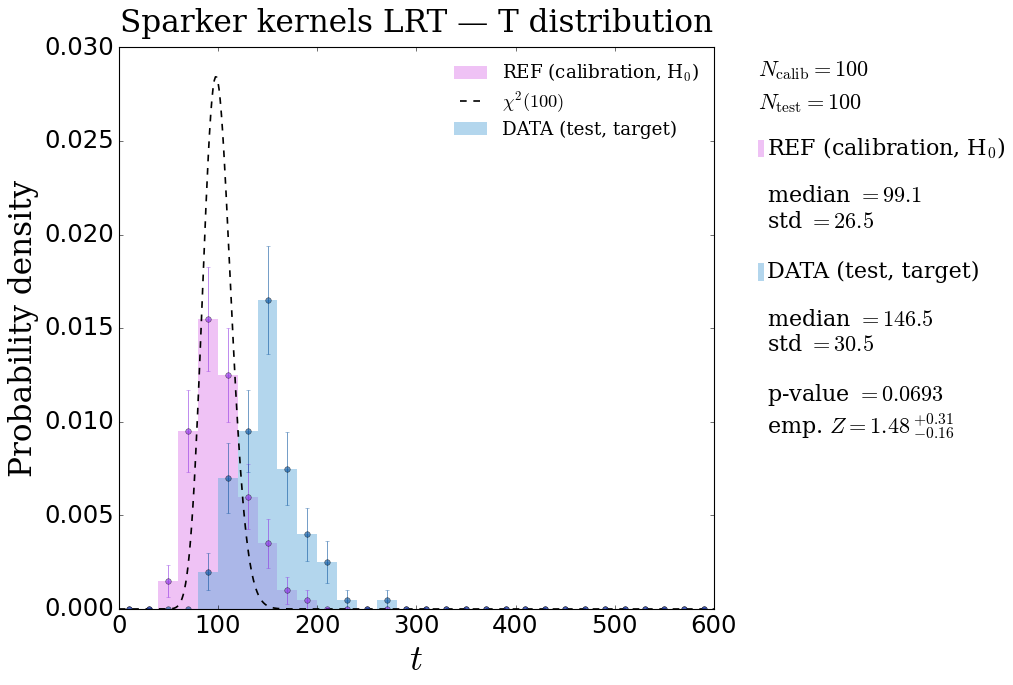

In [34]:
plot_T_distributions(
    t_calib, t_test,
    output_path=FIG_DIR,
    xmin=XMIN, xmax=XMAX, ymax=YMAX, nbins=NBINS,
    save=True,
    label1='REF (calibration, H$_0$)',
    label2='DATA (test, target)',
    save_name='T_distribution_Sparker',
    title='Sparker kernels LRT — T distribution',
    show_chi2=True,
    dof=DOF,
    scale_t=SCALE_T,
)

In [35]:
# Diagnostic: compare calibration quantiles to chi2(DOF)
label = '2T' if SCALE_T == 2 else 'T'
print(f"Calibration {label} vs chi2({DOF}) quantiles:")
print(f"{'quantile':>10}  {'data':>10}  {'chi2':>10}  {'ratio':>8}")
for q in [0.10, 0.25, 0.50, 0.75, 0.90]:
    d = float(np.quantile(t_calib, q))
    c = chi2.ppf(q, DOF)
    print(f"{q:>10.2f}  {d:>10.1f}  {c:>10.1f}  {d/c:>8.2f}")

Calibration T vs chi2(100) quantiles:
  quantile        data        chi2     ratio
      0.10        68.1        82.4      0.83
      0.25        81.9        90.1      0.91
      0.50        99.1        99.3      1.00
      0.75       117.6       109.1      1.08
      0.90       136.6       118.5      1.15
